In [88]:
from scipy.io import loadmat
import matplotlib.pyplot as plt
import numpy as np
from scipy.fft import ifft, fft, fftfreq, fftshift, ifft2, fft2
from scipy import signal
from scipy.io import wavfile
import plotly
import plotly.graph_objs as go
import plotly.express as px
from plotly.subplots import make_subplots
import pandas as pd
from datetime import datetime, timedelta
from audio_function import plot1, plot1_f, mean_data_sep, mean_autocorr_signal, corr_f, count_time, cos_sim, cr_arr_t, norm_max, load_mat, first_second_part, filt_freq, variation_data, t_arr_for_corr_t, df, audio_data49_3, audio_data49_2, audio_data16_3, audio_data16_2, sample_rate, audio_data49_1

In [107]:
sample_rate, audio_data_seism = wavfile.read('/Users/bogda/Desktop/Acoustics/Scientific/Исходные данные/ExpSummer2024/data_seismo.wav')


In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.signal import spectrogram, decimate

# def plot_perfect_spectrogram(audio_data, sample_rate, max_freq=550):
#     """
#     Строит спектрограмму со сверхвысоким разрешением и относительной шкалой в дБ.
    
#     Parameters:
#     audio_data (np.ndarray): Временной сигнал
#     sample_rate (int): Исходная частота дискретизации (Гц)
#     title (str): Заголовок графика
#     max_freq (int): Максимальная отображаемая частота (Гц)
#     """
    
#     # --- Шаг 1. Десимация (Понижение частоты дискретизации) ---
#     # Для анализа частот до 500 Гц избыточный sample_rate (например, 44100 Гц) вредит четкости.
#     # Безопасно сжимаем сигнал до 2000 Гц, увеличивая вертикальное разрешение в десятки раз.
#     target_sr = 400
#     downsample_factor = int(sample_rate / target_sr)
    
#     if downsample_factor > 1:
#         working_data = decimate(audio_data, downsample_factor)
#         working_sr = sample_rate / downsample_factor
#     else:
#         working_data = audio_data
#         working_sr = sample_rate

#     # --- Шаг 2. Параметры оконного преобразования Фурье ---
#     nperseg = 2048 
#     noverlap = int(nperseg * 0.875)  # Высокое перекрытие окон для гладкости времени
#     nfft = 16384                     # Огромный nfft (Zero-padding) для ультра-тонкой сетки частот

#     # --- Шаг 3. Расчет спектрограммы ---
#     frequencies, times, Sxx = spectrogram(
#         working_data, 
#         fs=working_sr, 
#         window='hann',       
#         nperseg=nperseg, 
#         noverlap=noverlap,
#         nfft=nfft,
#         scaling='density'
#     )
    
#     # --- Шаг 4. Перевод в ОТНОСИТЕЛЬНЫЕ децибелы ---
#     # Сначала считаем стандартные дБ
#     Sxx_db = 10 * np.log10(Sxx + 1e-10)
    
#     # Обрезаем данные по частоте до max_freq ДО нормировки, 
#     # чтобы искать пик только в интересующем нас полезном диапазоне
#     freq_mask = frequencies <= max_freq
#     display_Sxx = Sxx_db[freq_mask, :]
#     display_freqs = frequencies[freq_mask]
    
#     # Нормировка: вычитаем максимальное значение. 
#     # Теперь самый громкий пик на графике равен строго 0 дБ!
#     max_db = np.max(display_Sxx)
#     display_Sxx_relative = display_Sxx - max_db
    
#     # Динамический диапазон (Порог контрастности)
#     # Отсекаем всё, что тише пика более чем на 40 дБ. 
#     # Это полностью уберет "мыльный" фоновый туман, оставив только четкие гармоники.
#     vmin = -40  
#     vmax = 0    

#     # --- Шаг 5. Визуализация высокой резкости ---
#     plt.figure(figsize=(14, 7), dpi=150)
    
#     # interpolation='none' отключает внутреннее сглаживание пикселей в Matplotlib
#     plt.imshow(
#         display_Sxx_relative, 
#         cmap='magma', 
#         origin='lower', 
#         aspect='auto',
#         extent=[times[0], times[-1], display_freqs[0], display_freqs[-1]],
#         interpolation='none', 
#         vmin=vmin, 
#         vmax=vmax
#     )
    
#     # Оформление цветовой шкалы
#     cbar = plt.colorbar(format='%+3.0f дБ')
#     cbar.set_label('Уровень относительно пика (дБ)', fontsize=11)
    
#     # Оформление осей графика
    
#     plt.xlabel('Время (сек)', fontsize=12)
#     plt.ylabel('Частота (Гц)', fontsize=12)
    
#     plt.grid(False) 
#     plt.tight_layout()
#     plt.show()

# # --- Как запускать ---
# data = audio_data_seism[0]
# sr = sample_rate          
# plot_perfect_spectrogram(data, sr)

ValueError: The length of the input vector x must be greater than padlen, which is 27.

In [208]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram, decimate, butter, filtfilt

def plot_perfect_spectrogram(audio_data, sample_rate, 
                             start_min=0, start_sec=0, 
                             end_min=None, end_sec=None, 
                             channel=0, max_freq=550):
    """
    Строит спектрограмму со сверхвысоким разрешением для выбранного временного отрезка и канала.
    С предварительной полосовой фильтрацией в диапазоне 60-300 Гц.
    """
    
    # --- Шаг 1. Выбор канала (Выделение 1D сигнала) ---
    working_data = np.asarray(audio_data)
    
    if working_data.ndim > 1:
        if working_data.shape[0] < working_data.shape[1]:
            if channel >= working_data.shape[0]:
                raise ValueError(f"Запрошен канал {channel}, но в данных всего {working_data.shape[0]} каналов.")
            working_data = working_data[channel, :]
        else:
            if channel >= working_data.shape[1]:
                raise ValueError(f"Запрошен канал {channel}, но в данных всего {working_data.shape[1]} каналов.")
            working_data = working_data[:, channel]
            
    # --- Шаг 2. Полосовая фильтрация (60 - 300 Гц) ---
    # Используем фильтр Баттерворта 4-го порядка.
    # filtfilt применит его дважды (вперед и назад), что даст 8-й порядок и нулевой фазовый сдвиг!
    f_low = 60.0
    f_high = 499.0
    nyquist = 0.5 * sample_rate
    
    # Защита: проверка, что верхняя граница фильтра не превышает частоту Найквиста
    if f_high >= nyquist:
        raise ValueError(f"Верхняя частота фильтра ({f_high} Гц) должна быть меньше частоты Найквиста ({nyquist} Гц).")
        
    b, a = butter(4, [f_low / nyquist, f_high / nyquist], btype='band')
    working_data = filtfilt(b, a, working_data)
            
    # --- Шаг 3. Временная фильтрация (Вырезка фрагмента) ---
    t_start = start_min * 60 + start_sec
    idx_start = int(t_start * sample_rate)
    
    if end_min is not None or end_sec is not None:
        e_min = end_min if end_min is not None else 0
        e_sec = end_sec if end_sec is not None else 0
        t_end = e_min * 60 + e_sec
        idx_end = int(t_end * sample_rate)
    else:
        idx_end = len(working_data)
        t_end = len(working_data) / sample_rate
        
    if idx_start >= len(working_data):
        raise ValueError(f"Время начала ({t_start} сек) выходит за пределы длительности записи.")
    if idx_end > len(working_data):
        idx_end = len(working_data)
    if idx_start >= idx_end:
        raise ValueError("Время конца фрагмента должно быть строго больше времени начала!")
        
    working_data = working_data[idx_start:idx_end]

    # --- Шаг 4. Десимация (Понижение частоты дискретизации) ---
    # Так как мы ищем частоты до 300 Гц, таргетную частоту дискретизации 
    # безопасно увеличим до 800 Гц (чтобы уверенно перекрыть 300 Гц с запасом)
    target_sr = 1000
    downsample_factor = int(sample_rate / target_sr)
    
    if downsample_factor > 1:
        if len(working_data) <= 27:
            if len(working_data) > 9:
                working_data = decimate(working_data, downsample_factor, ftype='fir')
            else:
                working_data = working_data[::downsample_factor]
        else:
            working_data = decimate(working_data, downsample_factor)
            
        working_sr = sample_rate / downsample_factor
    else:
        working_sr = sample_rate

    # --- Шаг 5. Параметры оконного преобразования Фурье ---
    nperseg = 512
    
    if len(working_data) < nperseg:
        nperseg = 2**int(np.log2(len(working_data)))
        if nperseg < 8:
            raise ValueError(f"Вырезанный фрагмент слишком короткий для анализа.")
            
    noverlap = int(nperseg * 0.875)  
    nfft = max(16384, nperseg) 
    # --- Шаг 6. Расчет спектрограммы ---
    frequencies, times, Sxx = spectrogram(
        working_data, 
        fs=working_sr, 
        window='hann',       
        nperseg=nperseg, 
        noverlap=noverlap,
        nfft=nfft,
        scaling='density'
    )
    
    times += t_start
    
    # --- Шаг 7. Перевод в ОТНОСИТЕЛЬНЫЕ децибелы ---
    Sxx_db = 10 * np.log10(Sxx + 1e-5)
    
    freq_mask = frequencies <= max_freq
    display_Sxx = Sxx_db[freq_mask, :]
    display_freqs = frequencies[freq_mask]
    
    max_db = np.max(display_Sxx)
    display_Sxx_relative = display_Sxx - max_db
    
    vmin = -40
    vmax = -10

    # --- Шаг 8. Визуализация ---
    plt.figure(figsize=(14, 7), dpi=500)
    times = times - 3360
    plt.imshow(
        display_Sxx_relative, 
        cmap='magma',  # ТЕМНЫЙ фон (-60 дБ), СВЕТЛЫЕ/ЯРКИЕ линии (0 дБ)
        origin='lower', 
        aspect='auto',
        extent=[times[0], times[-1], display_freqs[0], display_freqs[-1]],
        interpolation='none', 
        vmin=vmin, 
        vmax=vmax
    )
    
    cbar = plt.colorbar(format='%+3.0f дБ')
    cbar.set_label('Относительная мощность, дБ', fontsize=11)
    
    plt.xlabel('Время, c', fontsize=12)
    plt.ylabel('Частота, Гц', fontsize=12)
    
    plt.grid(False) 
    plt.tight_layout()
    plt.show()

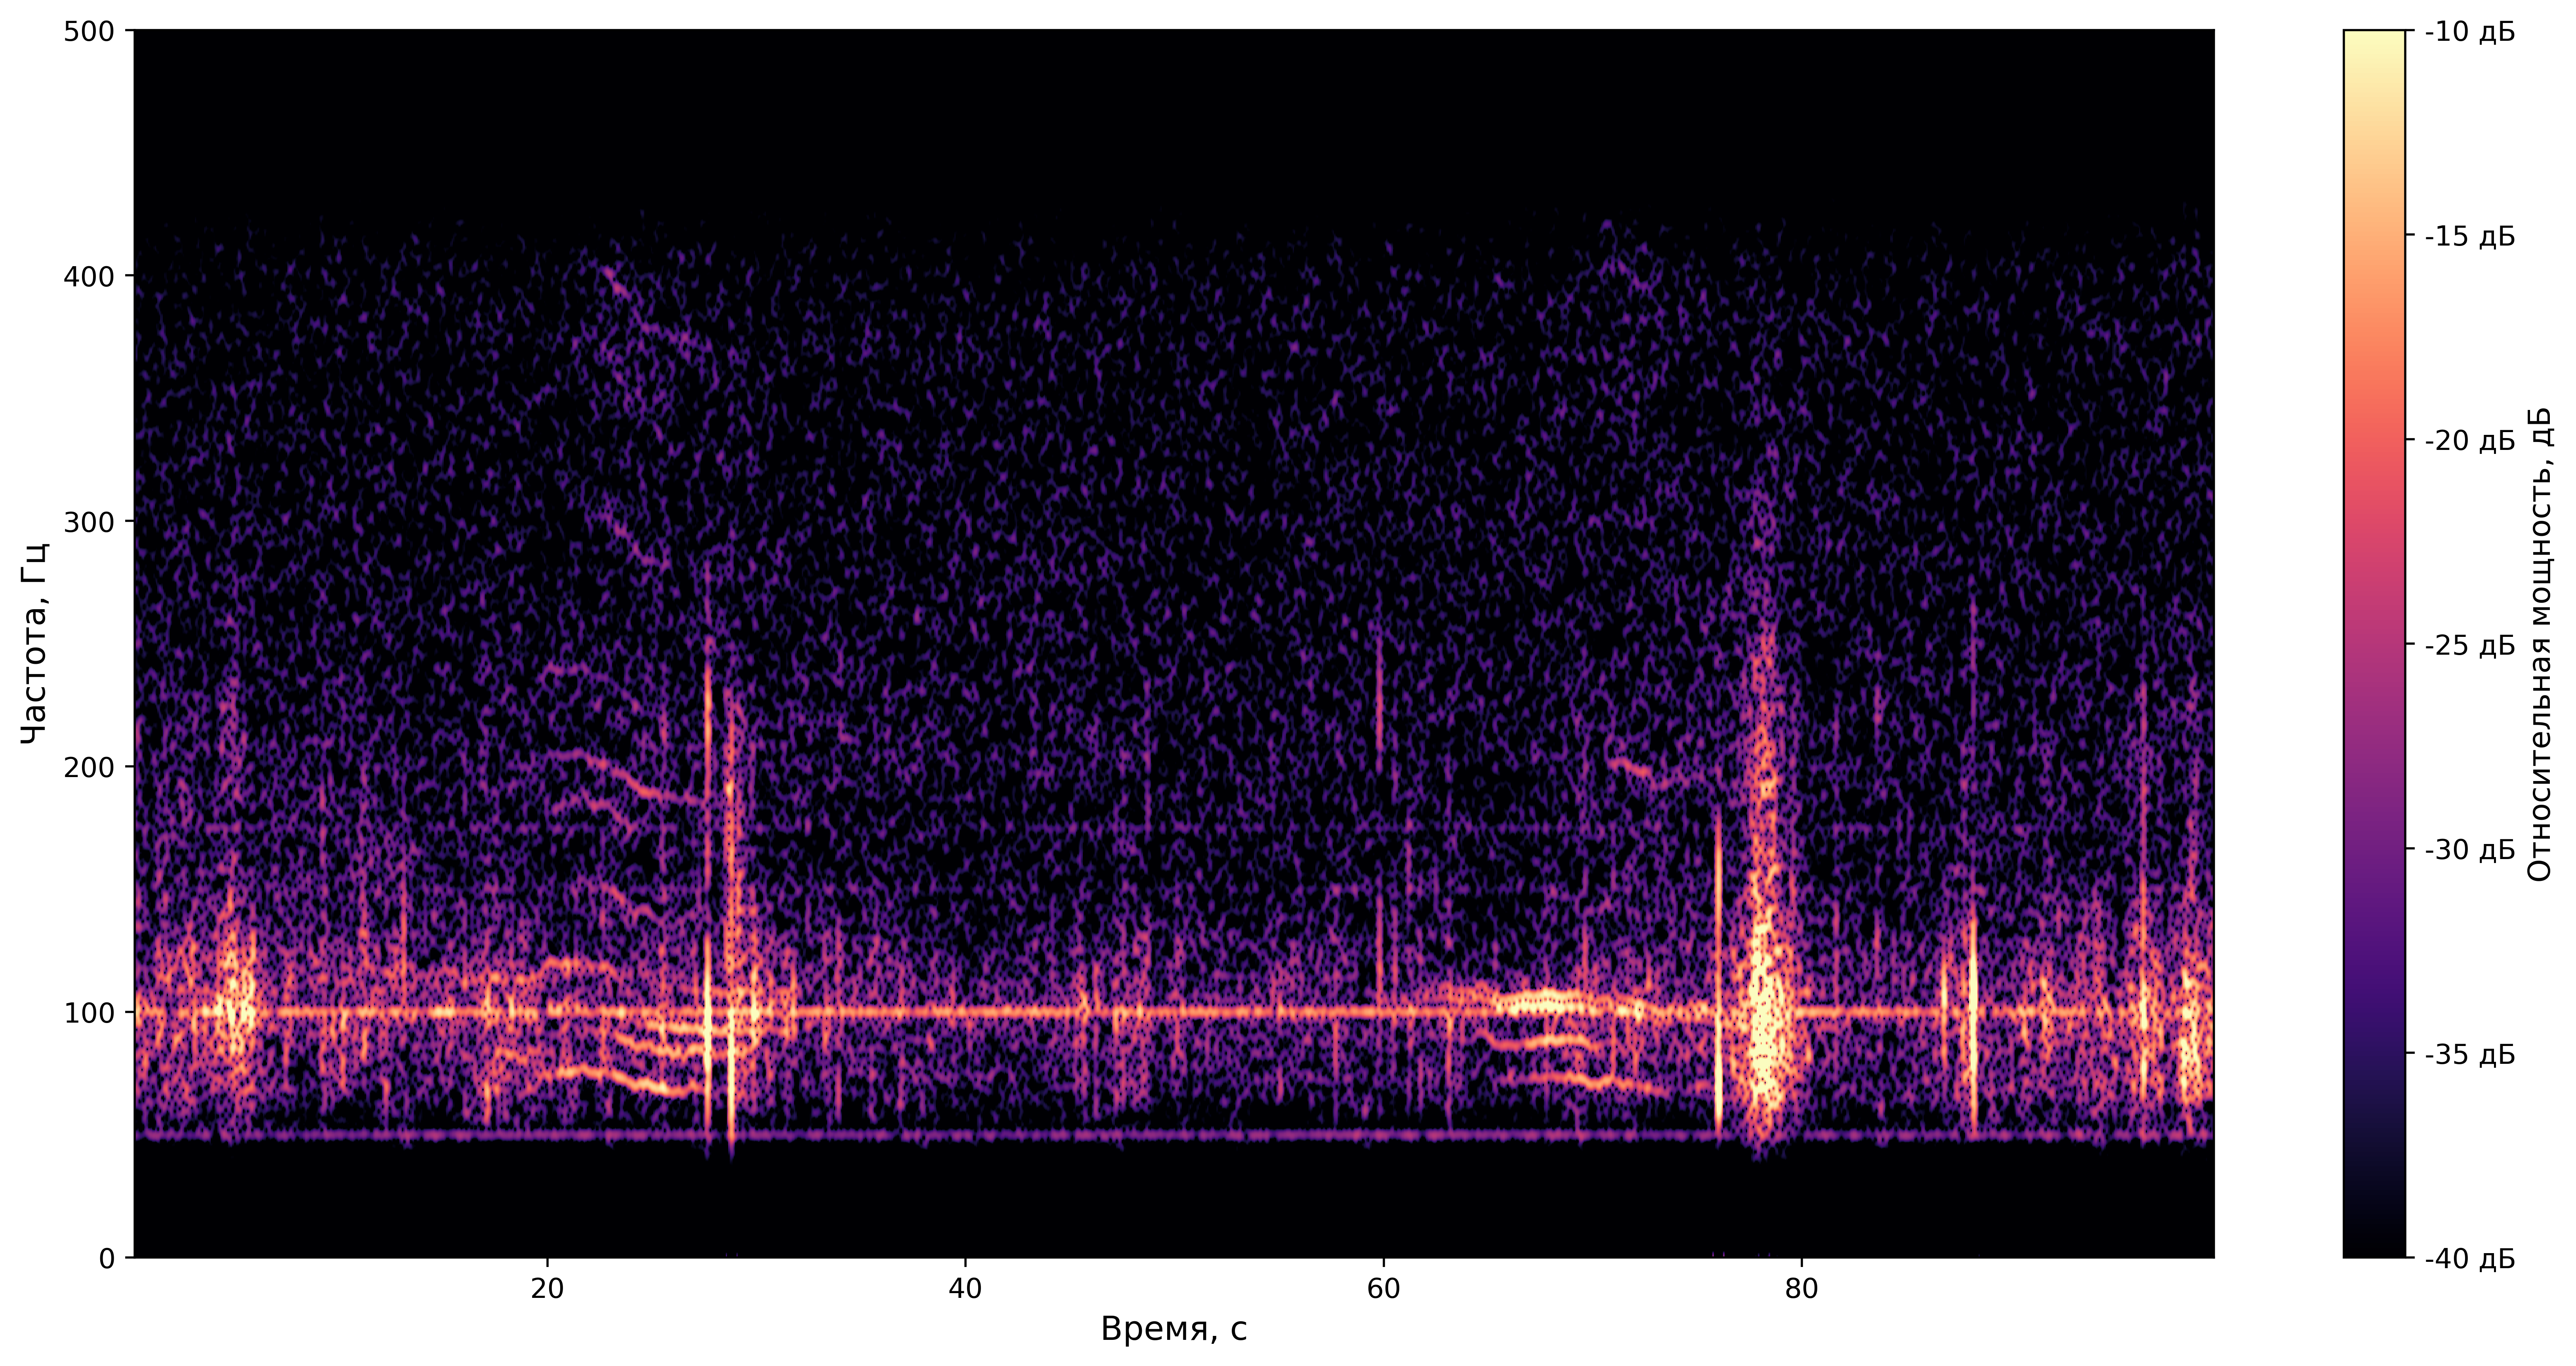

In [ ]:
data = audio_data_seism
sr = sample_rate          
plot_perfect_spectrogram(data, sr, start_min=56, start_sec=0, end_min=56, end_sec=40, channel=0)

In [316]:
import os
import numpy as np
from scipy.io import wavfile

def trim_audio_by_seconds(input_file_path, output_file_path, start_sec, duration_sec):
    """
    Вырезает фрагмент из аудиофайла на основе секунд и сохраняет его.
    
    Parameters:
    input_file_path (str): Путь к исходному .wav файлу
    output_file_path (str): Путь для сохранения готового фрагмента
    start_sec (float): Время начала вырезки (в секундах)
    duration_sec (float): Длительность вырезаемого куска (в секундах)
    """
    # 1. Читаем исходный файл
    # sample_rate — частота дискретизации (Гц), data — массив отсчетов
    sample_rate, data = wavfile.read(input_file_path)
    
    # Вычисляем общую длительность трека в секундах
    total_samples = data.shape[0]
    total_duration = total_samples / sample_rate
    print(f"Исходный файл успешно загружен. Общая длительность: {total_duration:.2f} сек.")
    
    # 2. Переводим секунды в индексы массива (отсчеты)
    start_index = int(start_sec * sample_rate)
    end_index = int((start_sec + duration_sec) * sample_rate)
    
    # 3. Валидация и защита от выхода за границы трека
    if start_index >= total_samples:
        raise ValueError(f"Ошибка! Точка начала ({start_sec} с) выходит за пределы файла ({total_duration:.2f} с).")
        
    if end_index > total_samples:
        print(f"Предупреждение: Заданный отрезок выходит за конец файла. Будет вырезано до упора.")
        end_index = total_samples
        
    # 4. Вырезаем кусок (работает корректно как для моно, так и для стерео/многоканальных записей)
    trimmed_data = data[start_index:end_index]
    
    # 5. Записываем результат в новый файл
    print(f"Фрагмент успешно сохранен в: {output_file_path}")
    print(f"Реальная длительность нового файла: {trimmed_data.shape[0]/sample_rate:.2f} сек.\n")
    return trimmed_data


# --- ПРИМЕР ИСПОЛЬЗОВАНИЯ ---
# Замените пути и параметры под свои данные:
input_wav = '/Users/bogda/Desktop/Acoustics/Scientific/Исходные данные/ExpSummer2024/data_seismo.wav'     # Имя вашего исходного файла
output_wav = "extracted_event.wav"     # Имя файла, куда запишется результат

start_time_1 = 3386.5
start_time_2 = start_time_1 + 1        
start_time_3 = start_time_1 + 3      
start_time_4 = start_time_1 + 4        
start_time_5 = start_time_1 + 5    
start_time_6 = start_time_1 + 6 
start_time_7 = 1875.0            
duration = 1.0                       

# Запуск функции
data_seism_1 = trim_audio_by_seconds(input_file_path=input_wav, output_file_path=output_wav, start_sec=start_time_1, duration_sec=duration)
data_seism_2 = trim_audio_by_seconds(input_file_path=input_wav, output_file_path=output_wav, start_sec=start_time_2, duration_sec=duration)
data_seism_3 = trim_audio_by_seconds(input_file_path=input_wav, output_file_path=output_wav, start_sec=start_time_3, duration_sec=duration)
data_seism_4 = trim_audio_by_seconds(input_file_path=input_wav, output_file_path=output_wav, start_sec=start_time_4, duration_sec=duration)
data_seism_5 = trim_audio_by_seconds(input_file_path=input_wav, output_file_path=output_wav, start_sec=start_time_5, duration_sec=duration)
data_seism_6 = trim_audio_by_seconds(input_file_path=input_wav, output_file_path=output_wav, start_sec=start_time_6, duration_sec=duration)
data_seism_7 = trim_audio_by_seconds(input_file_path=input_wav, output_file_path=output_wav, start_sec=start_time_7, duration_sec=duration)

Исходный файл успешно загружен. Общая длительность: 7860.00 сек.
Фрагмент успешно сохранен в: extracted_event.wav
Реальная длительность нового файла: 1.00 сек.

Исходный файл успешно загружен. Общая длительность: 7860.00 сек.
Фрагмент успешно сохранен в: extracted_event.wav
Реальная длительность нового файла: 1.00 сек.

Исходный файл успешно загружен. Общая длительность: 7860.00 сек.
Фрагмент успешно сохранен в: extracted_event.wav
Реальная длительность нового файла: 1.00 сек.

Исходный файл успешно загружен. Общая длительность: 7860.00 сек.
Фрагмент успешно сохранен в: extracted_event.wav
Реальная длительность нового файла: 1.00 сек.

Исходный файл успешно загружен. Общая длительность: 7860.00 сек.
Фрагмент успешно сохранен в: extracted_event.wav
Реальная длительность нового файла: 1.00 сек.

Исходный файл успешно загружен. Общая длительность: 7860.00 сек.
Фрагмент успешно сохранен в: extracted_event.wav
Реальная длительность нового файла: 1.00 сек.

Исходный файл успешно загружен. Об

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


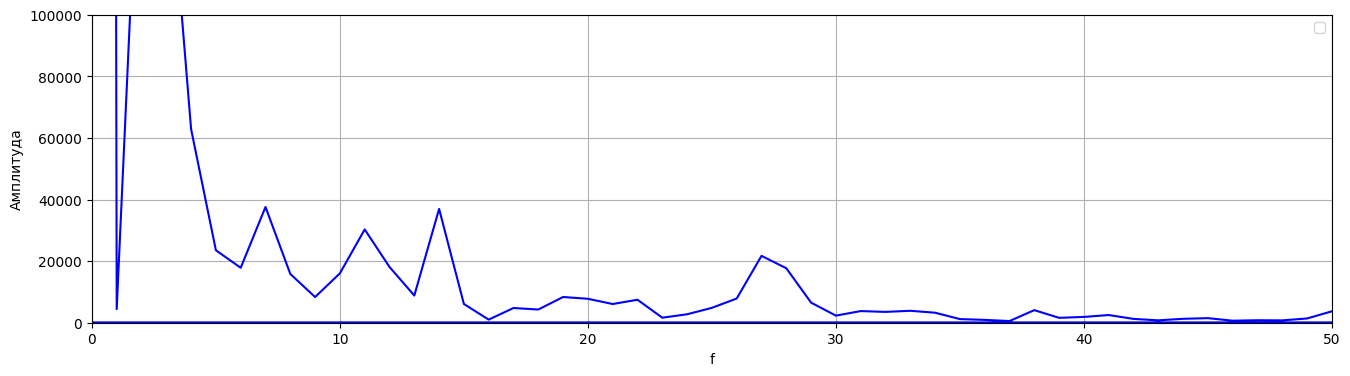

In [322]:
signal = data_seism_7[:,0] 
t = np.arange(len(signal))/sample_rate
f = fftfreq(len(signal), 1 / sample_rate)
plt.figure(figsize=(16,4))
plt.plot(f,np.abs(fft((signal))), color='blue')
plt.legend()
plt.xlabel("f")
plt.ylabel("Амплитуда")
plt.grid(True)
plt.xlim(0,50)
plt.ylim(-5, 1e5)
plt.show()

In [312]:
import plotly.graph_objects as go
import numpy as np

# Считаем спектры для новых данных
spectrum_1 = np.abs(fft(data_seism_1[:, 0]))
spectrum_2 = np.abs(fft(data_seism_2[:, 0]))
spectrum_3 = np.abs(fft(data_seism_3[:, 0]))
spectrum_4 = np.abs(fft(data_seism_4[:, 0]))
spectrum_5 = np.abs(fft(data_seism_5[:, 0]))
spectrum_6 = np.abs(fft(data_seism_6[:, 0]))


# Создаем интерактивное окно Plotly
fig = go.Figure()
t = np.arange(len(data_seism_1[:, 0])) / sample_rate

f = fftfreq(len(data_seism_1[:, 0]), 1/sample_rate)
# Списки данных для упаковки в цикл
spectrums = [spectrum_1, spectrum_2, spectrum_3, spectrum_4, spectrum_5, spectrum_6]
frequencies = [f, f, f, f, f, f]
colors = ['red', 'orange', 'blue', 'green', 'purple', 'brown']
labels = ['Спектр 1', 'Спектр 2', 'Спектр 3', 'Спектр 4', 'Спектр 5', 'Спектр 6']

# Добавляем графики
for f, s, color, label in zip(frequencies, spectrums, colors, labels):
    fig.add_trace(go.Scatter(
        x=f, 
        y=s, 
        mode='lines', 
        name=label,
        line=dict(color=color),
        hovertemplate='<b>%{text}</b><br>Частота: %{x:.2f} Гц<br>Амплитуда: %{y:.2f}<extra></extra>',
        text=[label] * len(f)
    ))

# Настраиваем отображение (сетка, размеры, ограничения осей)
fig.update_layout(
    xaxis_title='Частота, Гц',
    yaxis_title='Амплитуда, нормированная',
    xaxis=dict(range=[150, 200], showgrid=True, gridcolor='LightGray'),
    yaxis=dict(range=[0, 1200],showgrid=True, gridcolor='LightGray'),
    width=1000,
    height=400,
    margin=dict(l=40, r=40, t=50, b=40),
    template='plotly_white',
    hovermode='x unified' # При наведении показывает значения всех 6 спектров одновременно
)

# Выводим график на экран
fig.show()

In [283]:
np.std([926,618, 405, 688, 938, 644, 769, 664, 556, 902, 818])

159.98414177609826

In [ ]:
import numpy as np

def analyze_target_freq_to_std(spectrum_data, freq_array, target_freq, f_min, f_max):
    """
    Вырезает полосу [f_min, f_max] из спектра, находит амплитуду на заданной частоте target_freq
    (или ближайшей к ней) и делит её на STD спектра в этой полосе.
    
    Parameters:
    spectrum_data (np.ndarray): Массив амплитуд спектра (np.abs(fft(...)))
    freq_array (np.ndarray): Массив частот, соответствующий спектру
    target_freq (float): Целевая частота, значение которой нужно проверить (Гц)
    f_min (float): Нижняя граница частотной полосы для расчета STD (Гц)
    f_max (float): Верхняя граница частотной полосы для расчета STD (Гц)
    """
    # 1. Создаем маску полосы частот и обрезаем данные для расчета STD
    band_mask = (freq_array >= f_min) & (freq_array <= f_max)
    cropped_freqs = freq_array[band_mask]
    cropped_spectrum = spectrum_data[band_mask]
    
    if len(cropped_spectrum) == 0:
        print(f"Внимание: в диапазоне {f_min}-{f_max} Гц нет точек данных!")
        return 0.0, 0.0, 0.0
    
    # 2. Находим индекс ближайшей частоты к заданной target_freq во всем массиве
    # np.abs(freq_array - target_freq) находит разницу, а argmin() дает индекс минимальной разницы
    idx_closest = np.argmin(np.abs(freq_array - target_freq))
    
    actual_freq = freq_array[idx_closest]          # Точная частота, которая нашлась в массиве
    target_amplitude = spectrum_data[idx_closest]  # Амплитуда на этой частоте
    
    # 3. Считаем STD строго внутри указанной полосы
    spectrum_std = np.std(cropped_spectrum)
    
    # 4. Считаем отношение
    if spectrum_std == 0:
        ratio = 0.0
    else:
        ratio = target_amplitude / spectrum_std
        
    return actual_freq, target_amplitude, ratio

# --- Пример использования на ваших данных ---
# spectrum_1 = np.abs(fft(data_seism_6[:, 0]))
freqs = f
spectrum = [spectrum_1, spectrum_2, spectrum_3,  spectrum_5, spectrum_6]
my_freq = [186.0, 188.0, 187.0, 188.0, 189.0]# Частота, которую хотим проверить для каждого спектра
f_low = 183.0 # Границы полосы, в которой считаем фоновый шум (STD)
f_high = 194.0

act_f_arr = []
amp_arr = []
ratio_arr = []

for i in range(len(spectrum)):
    act_f, amp, ratio = analyze_target_freq_to_std(
        spectrum_data=spectrum[i], 
        freq_array=freqs, 
        target_freq=my_freq[i],
        f_min=f_low, 
    f_max=f_high
 )
    act_f_arr.append(act_f)
    amp_arr.append(amp)
    ratio_arr.append(ratio)

print(ratio_arr)
print(f"Задано: {my_freq} Гц. Ближайшая найденная точка в FFT: {act_f:.3f} Гц")
print(f"Амплитуда на этой частоте: {amp:.2f}")

print(f"Отношение заданной точки к STD полосы: {ratio:.2f}")

[4.035945419831239, 3.4545075976696165, 2.990093798657293, 3.851324171108442, 1.7395463376150302]
Задано: [186.0, 188.0, 187.0, 188.0, 189.0] Гц. Ближайшая найденная точка в FFT: 189.000 Гц
Амплитуда на этой частоте: 124.67
Отношение заданной точки к STD полосы: 1.74


In [292]:
import numpy as np

def analyze_target_freq_to_std(spectrum_data, freq_array, target_freq, f_min, f_max):
    """
    Вырезает полосу [f_min, f_max] из спектра, находит амплитуду на заданной частоте target_freq.
    Вычитает из неё среднее значение шума в этой полосе и делит результат на STD этой полосы.
    """
    # 1. Создаем маску полосы частот и обрезаем данные для расчета среднего и STD
    band_mask = (freq_array >= f_min) & (freq_array <= f_max)
    cropped_spectrum = spectrum_data[band_mask]
    
    if len(cropped_spectrum) == 0:
        print(f"Внимание: в диапазоне {f_min}-{f_max} Гц нет точек данных!")
        return 0.0, 0.0, 0.0
    
    # 2. Находим индекс ближайшей частоты к заданной target_freq
    idx_closest = np.argmin(np.abs(freq_array - target_freq))
    
    actual_freq = freq_array[idx_closest]          # Точная частота в массиве
    target_amplitude = spectrum_data[idx_closest]  # Амплитуда на этой частоте
    
    # 3. Считаем среднее значение (шумовую полку) и STD строго внутри полосы
    spectrum_mean = np.mean(cropped_spectrum)
    spectrum_std = np.std(cropped_spectrum)
    
    # 4. НОВАЯ ЛОГИКА: Вычитаем среднее и делим на STD (расчет SNR)
    if spectrum_std == 0:
        ratio = 0.0
    else:
        # Считаем, насколько пик возвышается над средним шумом
        ratio = (target_amplitude - spectrum_mean) / spectrum_std
        
    return actual_freq, target_amplitude, ratio

# --- Пример использования и цикл по всем спектрам ---

# Ваши исходные данные (f — массив частот, spectrum_X — массивы амплитуд)
freqs = f
# Собираем спектры в список (добавил spectrum_4, проверьте, нужен ли он вам)
spectrums = [spectrum_1, spectrum_2, spectrum_3, spectrum_4, spectrum_5, spectrum_6]

# Целевые частоты для каждого из 6 спектров соответственно
my_freqs = [186.0, 188.0, 187.0, 189.0, 189.0, 189.0] 

# Границы шумового окна вокруг пиков
f_low = 184.0 
f_high = 194.0

act_f_arr = []
amp_arr = []
ratio_arr = []

# Итерируемся по всем спектрам
for i in range(len(spectrums)):
    act_f, amp, ratio = analyze_target_freq_to_std(
        spectrum_data=spectrums[i], 
        freq_array=freqs, 
        target_freq=my_freqs[i],
        f_min=f_low, 
        f_max=f_high
    )
    act_f_arr.append(act_f)
    amp_arr.append(amp)
    ratio_arr.append(ratio)

# Красивый вывод результатов
print("--- РЕЗУЛЬТАТЫ РАСЧЕТА (SNR) ---")
for i, r in enumerate(ratio_arr):
    print(f"Спектр {i+1}: Задано {my_freqs[i]} Гц (факт: {act_f_arr[i]:.2f} Гц) -> Итоговый Ratio (SNR): {r:.2f}")

print("\nМассив всех отношений:", ratio_arr)

--- РЕЗУЛЬТАТЫ РАСЧЕТА (SNR) ---
Спектр 1: Задано 186.0 Гц (факт: 186.00 Гц) -> Итоговый Ratio (SNR): 2.19
Спектр 2: Задано 188.0 Гц (факт: 188.00 Гц) -> Итоговый Ratio (SNR): 1.23
Спектр 3: Задано 187.0 Гц (факт: 187.00 Гц) -> Итоговый Ratio (SNR): -0.73
Спектр 4: Задано 189.0 Гц (факт: 189.00 Гц) -> Итоговый Ratio (SNR): 0.50
Спектр 5: Задано 189.0 Гц (факт: 189.00 Гц) -> Итоговый Ratio (SNR): -1.16
Спектр 6: Задано 189.0 Гц (факт: 189.00 Гц) -> Итоговый Ratio (SNR): -1.00

Массив всех отношений: [2.1928039180512404, 1.225409170436239, -0.7296898998388534, 0.5010832688035495, -1.1640017654712544, -0.998633956924632]


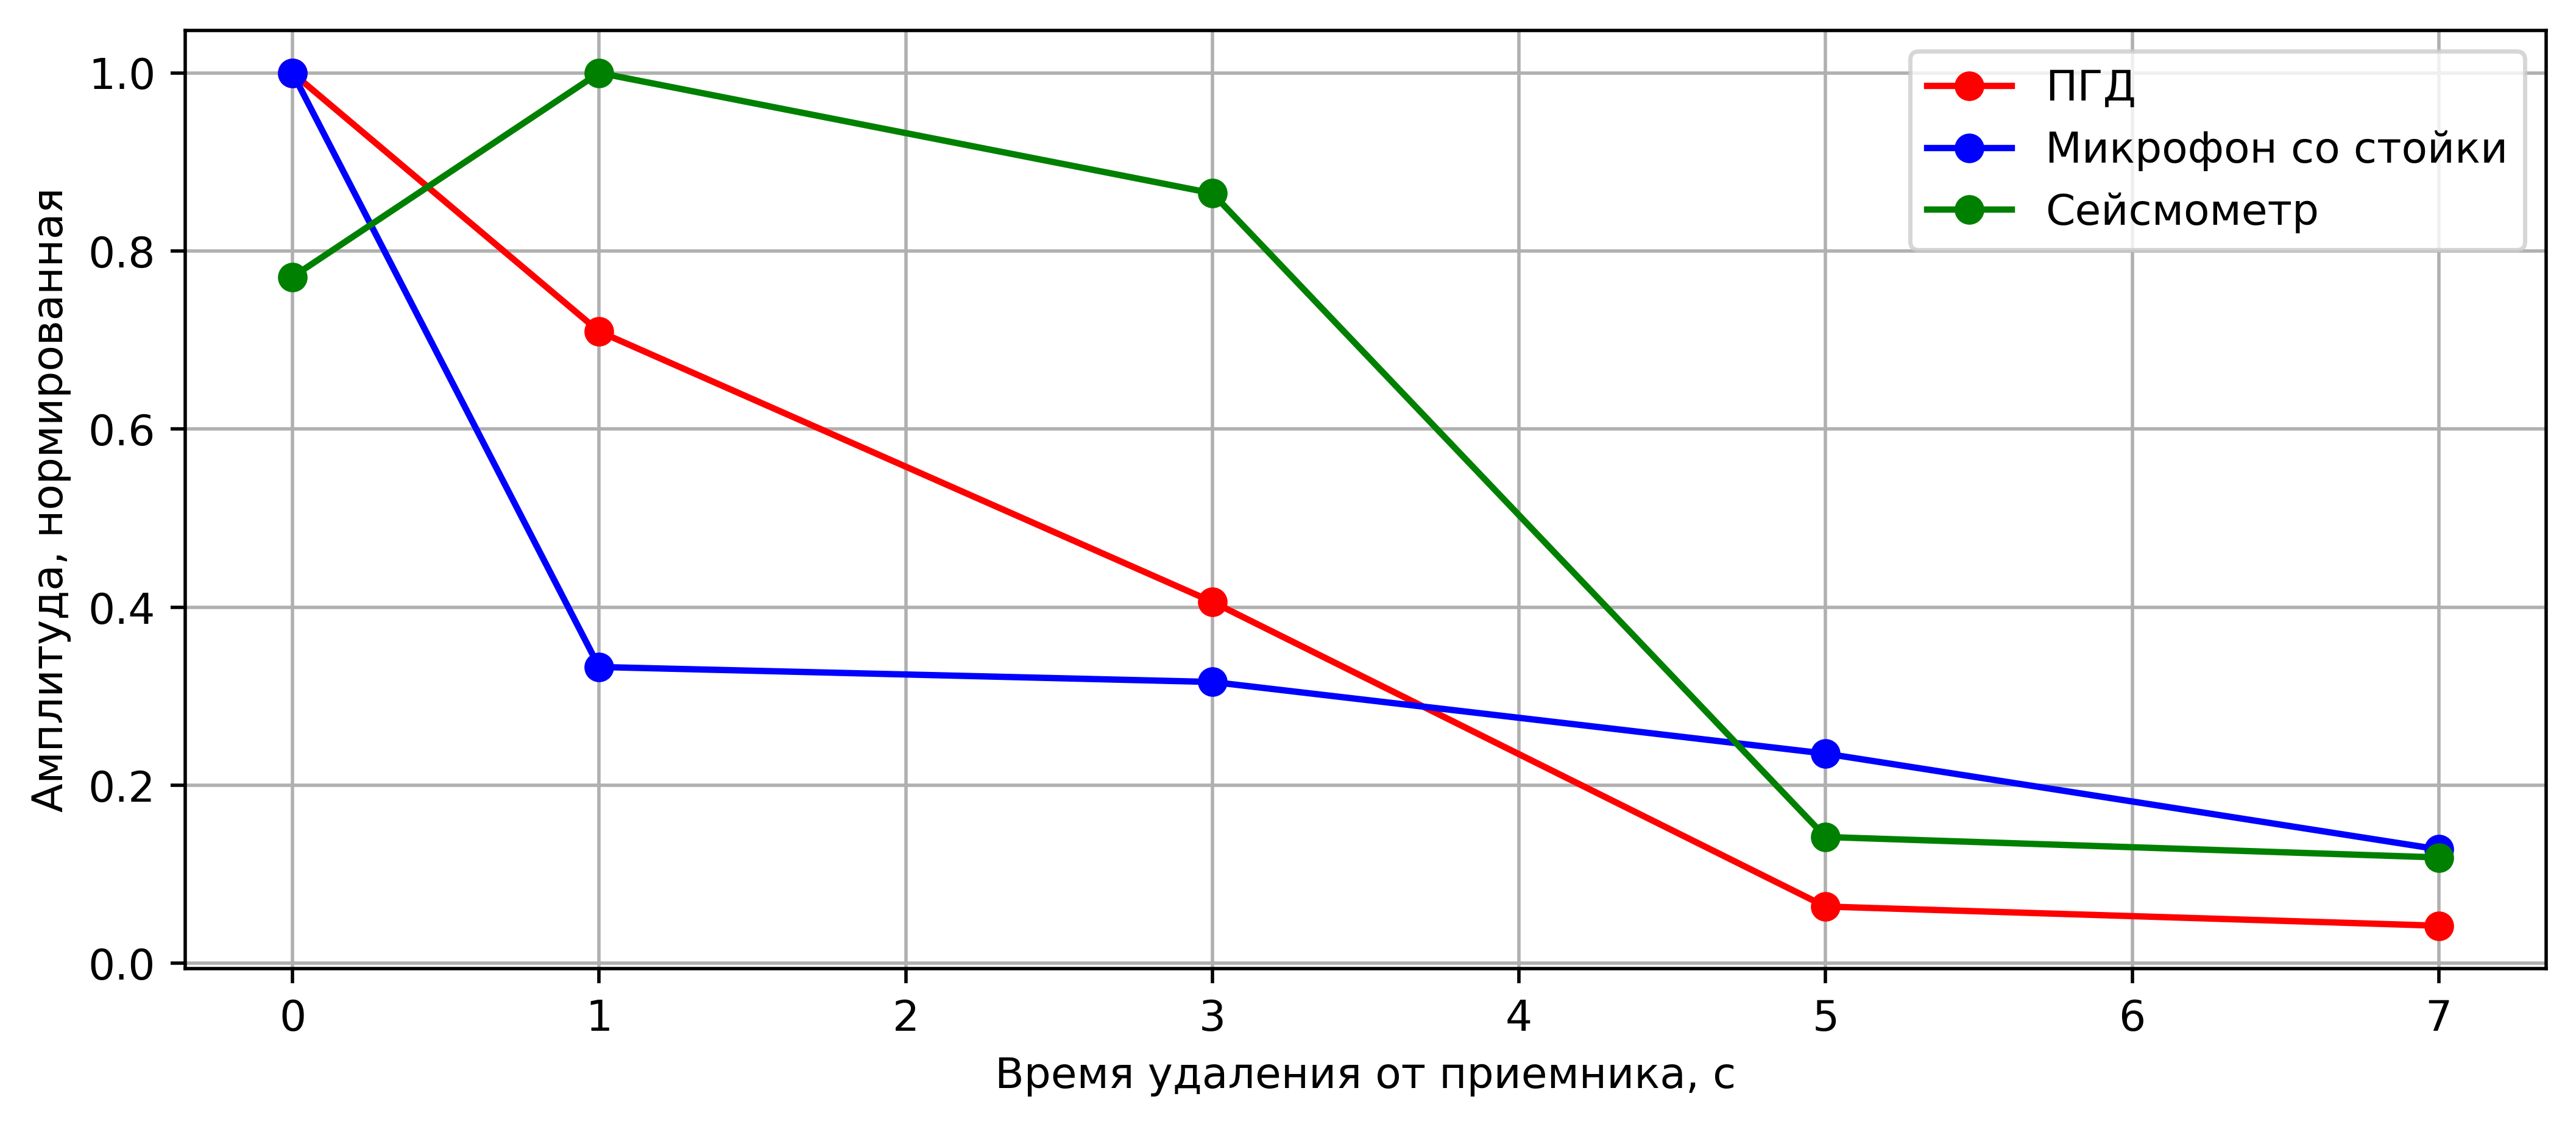

In [315]:
amplitude_pgd = [116461, 82641, 47285,  7428, 4916]
amplitude_micr_stable = [110939, 36921, 35053, 26129, 14200]
amplitude_seism = [804, 1043, 902, 148, 124]
amplitude_pgd = amplitude_pgd/np.max(amplitude_pgd)
amplitude_micr_stable = amplitude_micr_stable/np.max(amplitude_micr_stable)
amplitude_seism = amplitude_seism/np.max(amplitude_seism)
distance = [0, 1, 3,  5, 7]

plt.figure(figsize=(10,4), dpi=500)
plt.plot(distance, amplitude_pgd, color='red', marker='o')
plt.plot(distance, amplitude_micr_stable, color='blue', marker='o')
plt.plot(distance, amplitude_seism, color='green', marker='o')
plt.xlabel('Время удаления от приемника, с')
plt.ylabel('Амплитуда, нормированная')
plt.legend(['ПГД', 'Микрофон со стойки', 'Сейсмометр'])
plt.grid(True)
plt.show()

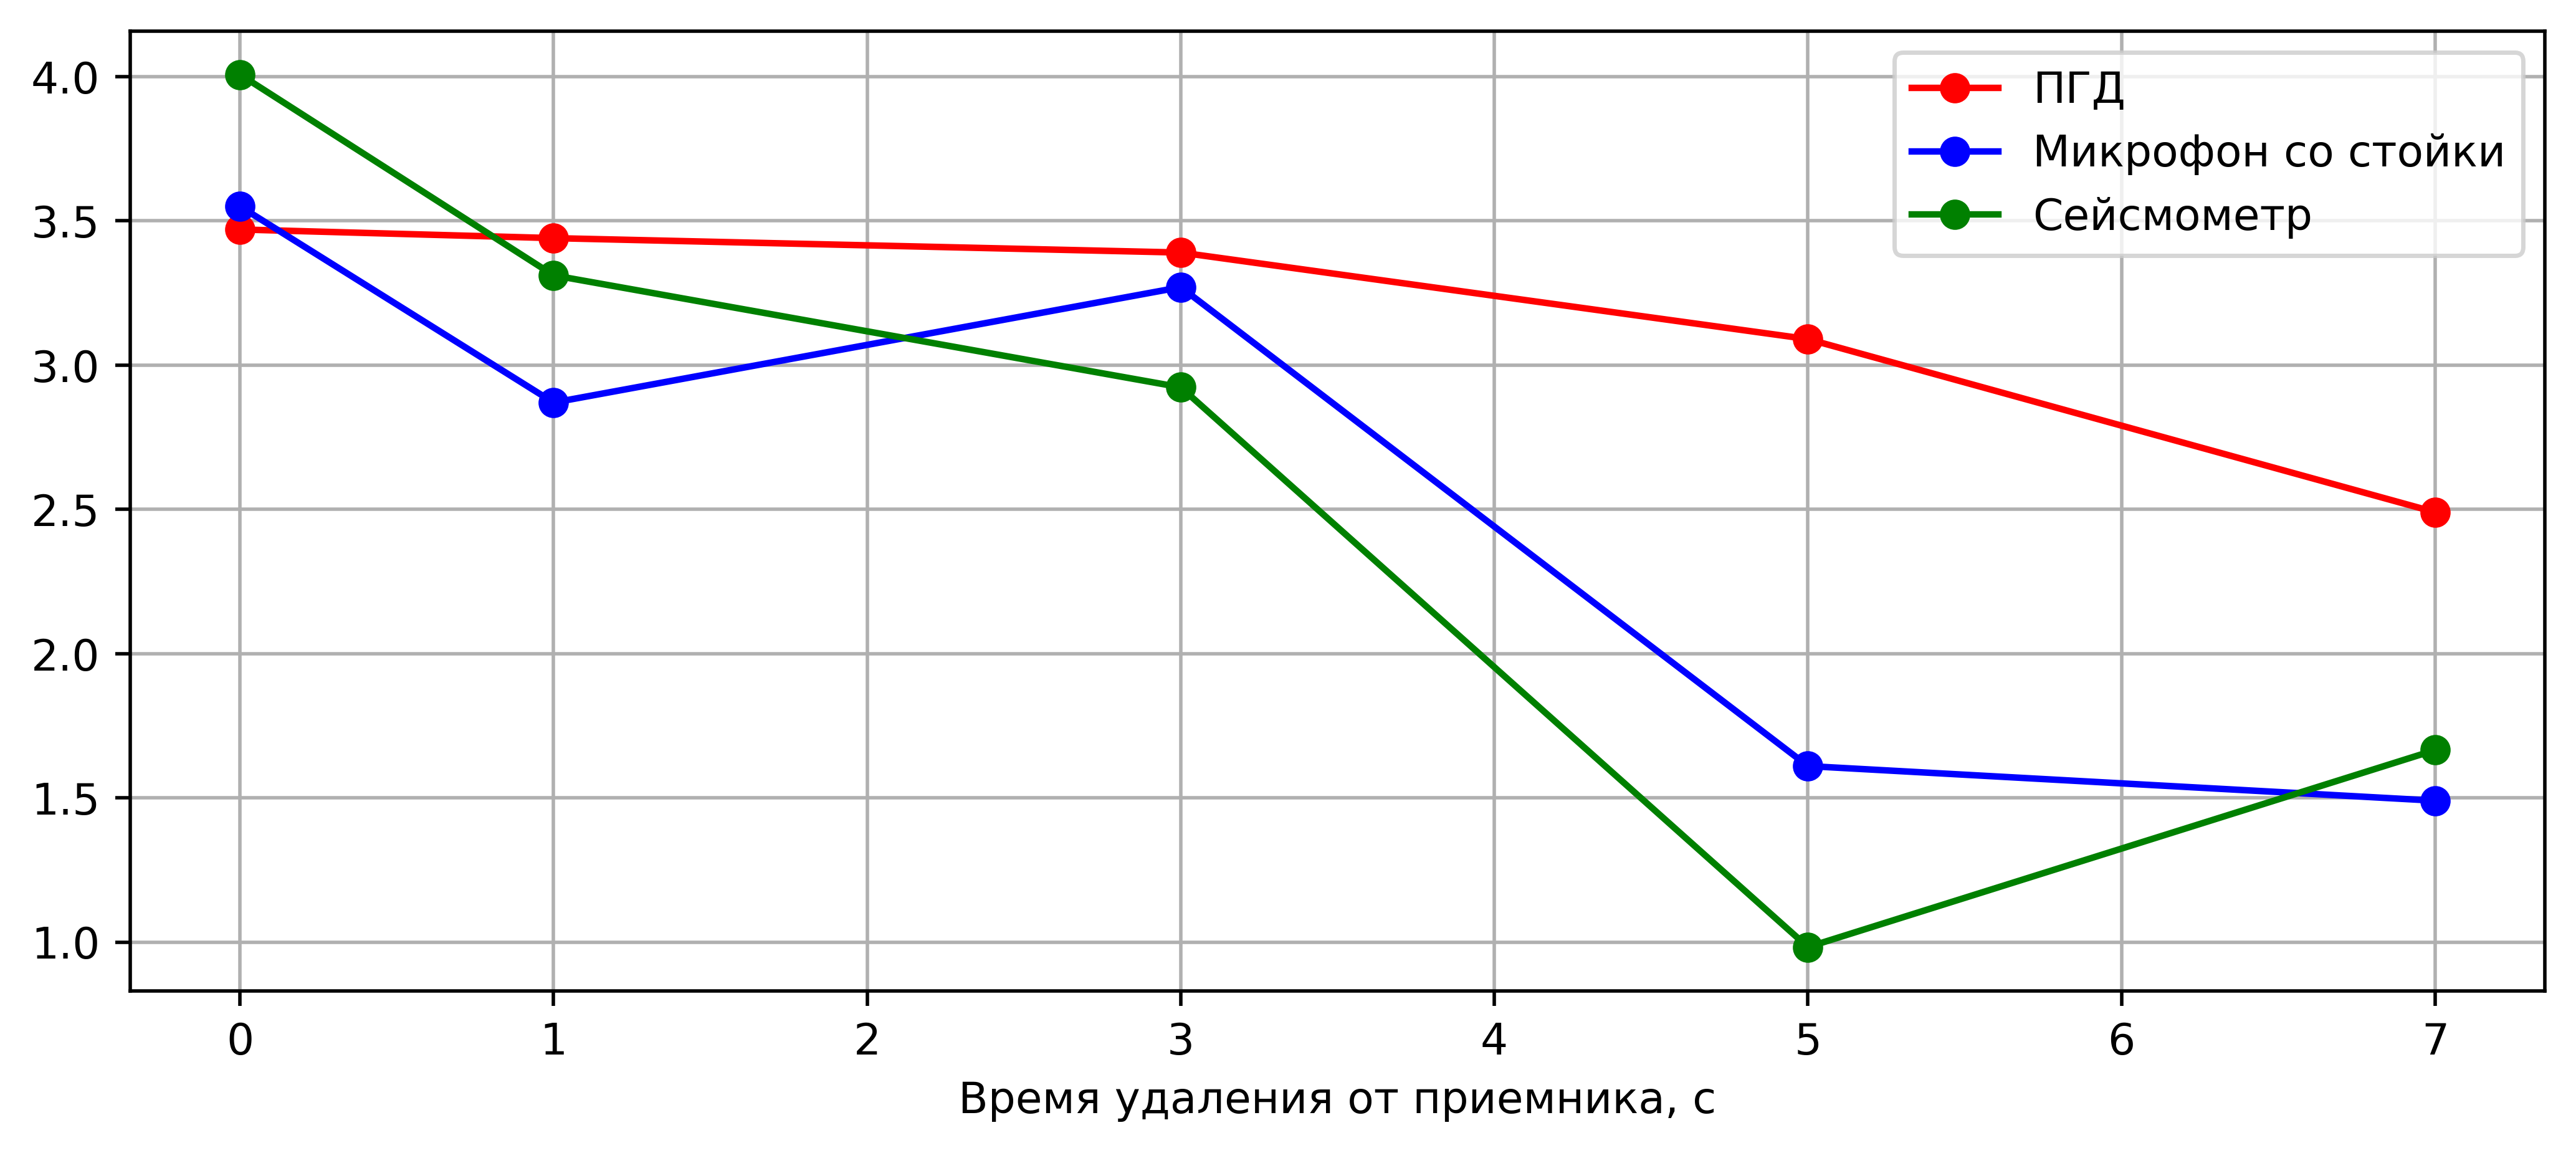

In [293]:
amplitude_pgd = [3.47, 3.44, 3.39,  3.09, 2.49]
amplitude_micr_stable = [3.55, 2.87, 3.27, 1.61, 1.49]
amplitude_seism = [4.007006169424741, 3.31096884799204, 2.922896805002915, 0.9825327320480076, 1.6655112439022441]

amplitude_micr_stable = amplitude_micr_stable
distance = [0, 1, 3,  5, 7]

plt.figure(figsize=(10,4), dpi=500)
plt.plot(distance, amplitude_pgd, color='red', marker='o')
plt.plot(distance, amplitude_micr_stable, color='blue', marker='o')
plt.plot(distance, amplitude_seism, color='green', marker='o')
plt.xlabel('Время удаления от приемника, с')
plt.legend(['ПГД', 'Микрофон со стойки', 'Сейсмометр'])
plt.grid(True)
plt.show()